# Demonstration of concurrent AA-CG building of linear polymer chains

In [1]:
# import dependencies
import logging
logging.basicConfig(
    level=logging.WARNING,
    # level=logging.DEBUG,
    force=True,
)
from rich.progress import Progress, BarColumn, TimeRemainingColumn

from typing import Iterable, Mapping
from enum import StrEnum

import json
from pathlib import Path

import numpy as np

from mupt.geometry.shapes import Ellipsoid, Sphere
from mupt.geometry.coordinates.reference import CoordAxis, origin
from mupt.geometry.transforms.rigid import rigid_vector_coalignment

from mupt.mupr.primitives import Primitive, PrimitiveHandle

from mupt.interfaces.rdkit import primitive_to_rdkit, suppress_rdkit_logs
from mupt.interfaces.smiles import primitive_from_smiles

In [2]:
# helper utilities for polymer sequencing
def build_progress() -> Progress:
    '''A nice-looking progress bar to track the coordinate generation of polymer chain assembly'''
    return Progress(
        "[progress.description]{task.description}",
        BarColumn(),
        "(polymer {task.completed}/{task.total})",
        TimeRemainingColumn(),
        "Placing {task.fields[chain_len]}-mer chain",
        auto_refresh=False,
    )

class TerminalGroup(StrEnum):
    '''For indicating orientation of terminal monomers'''
    HEAD = 'head'
    TAIL = 'tail'

def sequence_repeat_units(
    chain_len : int,
    head_name : str,
    tail_name : str,
    mid_distrib : Mapping[str, float],
) -> Iterable[str]:
    '''
    Generate a sequence of repeat unit names for a polymer chain
    
    Parameters
    ----------
    chain_len : int
        Total length of the polymer chain (number of repeat units, including end groups)
    head_name : str
        Name of the head repeat unit
    tail_name : str
        Name of the tail repeat unit
    mid_distrib : Mapping[str, float]
        Distribution of mid repeat units (map from names to probabilities of occurrence)
        Probabilities must sum to 1.0
    '''
    if chain_len < 2:
        raise ValueError('Chain length must be at least 2 to accommodate head and tail units')
    
    yield head_name
    for mid_name in np.random.choice(
        list(mid_distrib.keys()),
        size=(chain_len - 2),
        p=list(mid_distrib.values()), # NOTE: will raise Exception if not probabilities don't sum to 1 (no need to chekc ourselves)
    ).astype(object): # ccoerce back from numpy types
        yield mid_name
    yield tail_name

## Compile lexicon of unit repeat units
Here we specify all distinct, unique chemical fragments as they appear within a polymer chain (imagine "cutting" up a complete chain into its repeat units).
Each fragment is defined by a SMILES string, with two "edge" atoms marked out by map numbers 1 and 2 indicating the head/tail direction that repeat unit should face along a chain. 
"1" points forward ("ANTERO") in the head-to-tail direction, while "2" points backward ("RETRO") in the tail-to-head direction.
Sites with opposite direction are designated compatible for chain bonds, while those with matching direction are not.

For the example below, a lexicon is provided as a mapping of repeat unit names (could be anything) to 1-2 labelled SMILES strings, assigned to `rep_unit_smiles` below. You can define your own lexicon there, or load a pre-compiled one from the accompanying `repeat_unit_SMILES.json`, where we've compiled valid labelled SMILES for some common polymer systems. If opting for the latter, specify which polymer system you'd like by choosing a value for `polymer_chemistry` from any of the following:
* 'polyethylene'
* 'polystyrene'
* 'polyethersulfone'
* 'polymethyl-methacrylate'
* 'poly(4-vinylpyridine)'
* 'polyvinylchloride'
* 'polyacrylamide
* 'natural rubber'

In either case, specify the repeat units that will go in each polymer chain in the systems by setting:
* The relative distribution of middle repeat units in `rep_unit_distrib_mid`, which maps middle repeat unit names to probabilities (must add up to 1.0!)
* The orientation of end groups in `end_groups`, which maps `TerminalGroup.HEAD`/`TerminalGroup.TAIL` to the names of 1-functional repeat unit fragments

In [3]:
SMILES_EXAMPLES_PATH = Path('./repeat_unit_SMILES.json')
with SMILES_EXAMPLES_PATH.open('r') as file:
    smiles_examples = json.load(file)

In [4]:
# configure polymer chemistry fragments, middle repeat unit distribution, and terminal group orientation here
polymer_chemistry : str = 'polyethersulfone'
rep_unit_smiles : dict[str, str] = smiles_examples[polymer_chemistry]
# rep_unit_smiles : dict[str, str] = {...} # if providing your own templates, inject repeat unit names and SMILES here
print(rep_unit_smiles.keys())

# NOTE: you will have to change the names below, according to the particular polymer chemistry you've chosen
# rep_unit_distrib_mid : dict[str, float] = { # PES homopolymer
#     'mid_bisphenol_S' : 1.0, 
# }
rep_unit_distrib_mid : dict[str, float] = { # PSU copolymer
    'mid_bisphenol_S' : 0.4,
    'mid_bisphenol_A' : 0.6,
}
end_groups : dict[TerminalGroup, str] = {
    TerminalGroup.HEAD : 'head_bisphenol_A',
    TerminalGroup.TAIL : 'tail_bisphenol_A',
}

dict_keys(['head_bisphenol_S', 'mid_bisphenol_S', 'tail_bisphenol_S', 'head_bisphenol_A', 'mid_bisphenol_A', 'tail_bisphenol_A'])


### Assigning encompassing shapes to repeat units
The marked sites will also be used to fit an encompassing rigid "shape" (Sphere or Ellipsoid in this demo) over the atomic conformer for each fragment.
The tips of the ellipsoid will be placed coincident with the marked atoms and span its major axis, while the lengths of the perpendicular minor axes are set equal to one another relative to the major axis length by the `SEMIMINOR_FRACT` parameter below.
In the future, this relationship will be inverted, i.e. first setting the bead size, then relaxing the atomic conformer to fit the body. 
This shape is useful for a coarse-grained representation of the system (e.g. Kremer-Grest beads) which remains synchronized during backmap

head_bisphenol_S


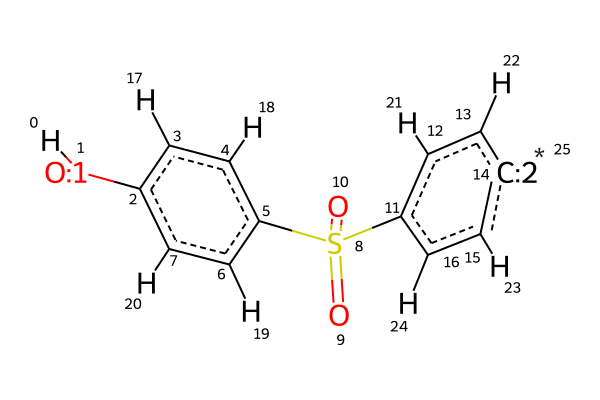

mid_bisphenol_S


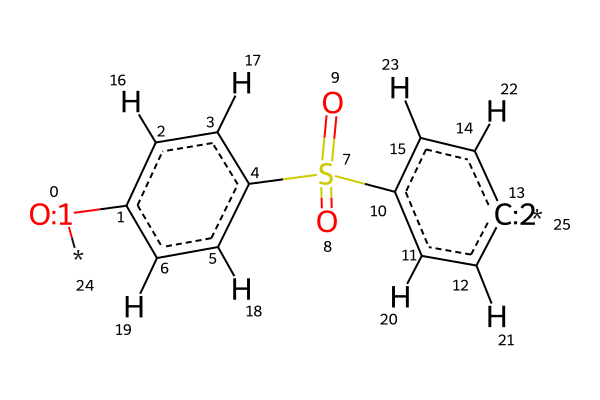

tail_bisphenol_S


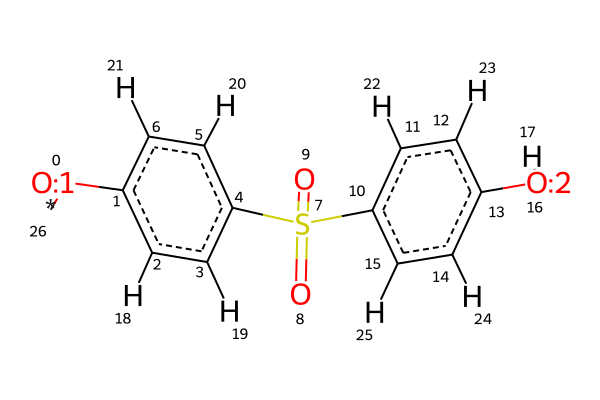

head_bisphenol_A


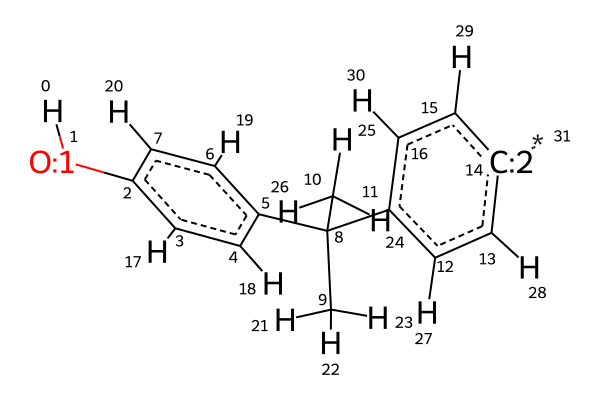

mid_bisphenol_A


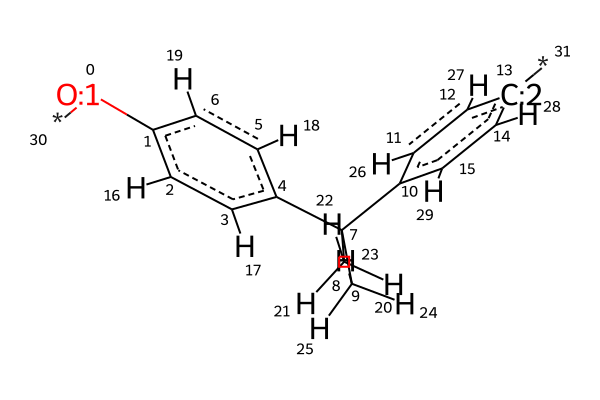

tail_bisphenol_A


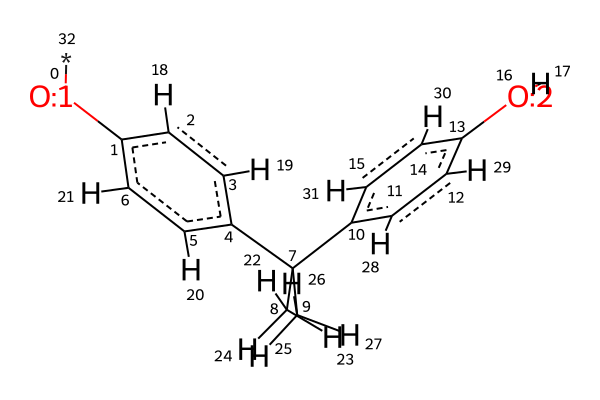

In [5]:
AXIS : CoordAxis = CoordAxis.X
SEMIMINOR_FRACT : float = 0.5 # how long the pair of minor axes should be as a fraction of the major axis length

lexicon : dict[str, Primitive] = {}
with suppress_rdkit_logs():
    for unit_name, smiles in rep_unit_smiles.items():
        unitprim = primitive_from_smiles(
            smiles,
            ensure_explicit_Hs=True,
            embed_positions=True,
            label=unit_name,
        )
            
        # force edge atoms to lie along chosen axis, with midpoint at the origin
        head_atom, tail_atom = unitprim.search_hierarchy_by(lambda prim : 'molAtomMapNumber' in prim.metadata, min_count=2)
        head_pos, tail_pos = head_atom.shape.centroid, tail_atom.shape.centroid
        
        major_radius = np.linalg.norm(tail_pos - head_pos) / 2.0
        axis_vec = np.zeros(3, dtype=float)
        axis_vec[AXIS.value] = major_radius
        axis_alignment = rigid_vector_coalignment(
            vector1_start=head_pos,
            vector1_end=tail_pos,
            vector2_start=origin(3),
            vector2_end=axis_vec,
            t1=1/2,
            t2=0.0,
        )
        unitprim.rigidly_transform(axis_alignment)
        lexicon[unit_name] = unitprim
        
        # set enveloping body around repeat unit - not necessary for backmap, but allows sphere placement for e.g. Kremer-Grest models
        semiminor = SEMIMINOR_FRACT * major_radius
        radii = np.full(3, semiminor)
        radii[AXIS.value] = major_radius
        unitprim.shape = Ellipsoid(radii) # = Sphere(major_radius)
        
        # show RDKit depiction of aligned repeat unit
        rdmol = primitive_to_rdkit(unitprim)
        print(unit_name)
        display(rdmol)

## Construct hierarchy of Primitives representing polymer system
The MuPT representation constructed here corresponds to a polydisperse box of polymer chains with a given distribution of lengths.
Each branch traced down through the hierarchy defined here corresponds to "universe -> molecule -> repeat unit -> atom", in order. This is not *remotely* the only way one could decompose a molecular system, but it's a fairly standard one for atomistic simulations which we present here for ease of understanding.

Each chain's units begin in reference position (i.e. centered at origin with ellipsoid axes aligned to coordinate axes), and are then moved into place in order by a placement generator.
An angle-constrained random walk is provided as an example implementation, but other implementations (e.g. DPD) can be slotted in just as easily by replacing the kind of `PlacementGenerator` is initialized in the `builder` variable 

In [6]:
# configure polymer chain parameters
R_excl : float = 10.0
bond_length : float = 1.5 # 5.5
angle_max_rad : float = np.pi/4

n_chains : int = 4
chain_len_min : int = 10
chain_len_max : int = 15

Output()

universe
├── 11-mer_chain
├── 12-mer_chain
├── 10-mer_chain
└── 13-mer_chain


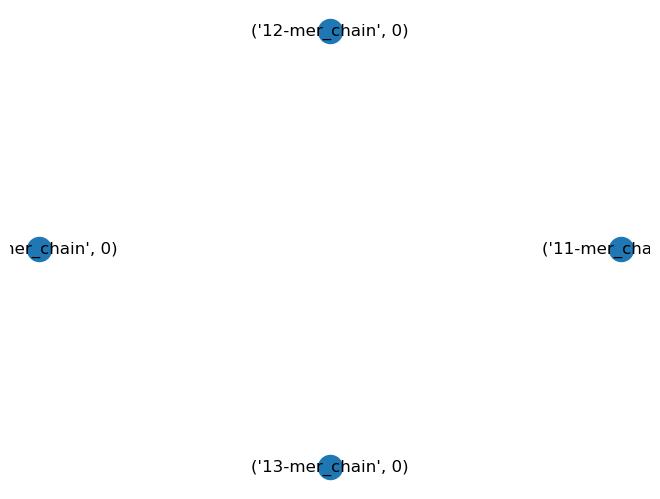

In [7]:
import networkx as nx
from mupt.mupr.topology import TopologicalStructure

from mupt.builders.random_walk import AngleConstrainedRandomWalk
from mupt.geometry.coordinates.directions import random_unit_vector


univprim = Primitive(label='universe')
with build_progress() as progress:
    task = progress.add_task('Building chains', total=n_chains, chain_len=0)
    for chain_len in np.random.randint(chain_len_min, chain_len_max + 1, size=n_chains):
        progress.update(task, chain_len=chain_len)
        
        # build chain hierarchy
        molprim = Primitive(label=f'{chain_len}-mer_chain')
        for i, unit_name in enumerate(
            sequence_repeat_units(
                chain_len,
                head_name=end_groups[TerminalGroup.HEAD],
                tail_name=end_groups[TerminalGroup.TAIL],
                mid_distrib=rep_unit_distrib_mid,
            )
        ):
            rep_unit_prim = lexicon[unit_name].copy()
            molprim.attach_child(rep_unit_prim)
            
        # assign path graph as topology, connecting adjacent Primitives
        molprim.set_topology(
            nx.path_graph(
                molprim.children_by_handle.keys(),
                create_using=TopologicalStructure,
            ),
            max_registration_iter=100,
        )

        # place beads by random walk (other build implementations would go here)
        direction = random_unit_vector()
        builder = AngleConstrainedRandomWalk(
            bond_length=bond_length,
            angle_max_rad=angle_max_rad,
            initial_point=R_excl*direction,
            initial_direction=direction,  # randomize starting direction to reduce likelihood of collisions
        )
        for handle, placement in builder.generate_placements(molprim):
            molprim.children_by_handle[handle].rigidly_transform(placement)
            
        # attach chain to universe, expand to show topology of beads
        mol_handle = univprim.attach_child(molprim)
        # univprim.expand(mol_handle)
        
        progress.advance(task)
        progress.refresh()

univprim.visualize_topology()
print(univprim.hierarchy_summary(to_depth=2))

## Shift down to finer levels of molecular resolution
The above topology appears fairly inocuous, because we are looking at a very coarse level of resolution, namely "one bead per molecule"  
This is where the "multiscale" part of the toolkit comes in - the MuPT representation can readily shift resolutions to view finer subdivisions of our molecular system. We may for instance "expand" each of the molecules above, replacing them with their constituent repeat units instead

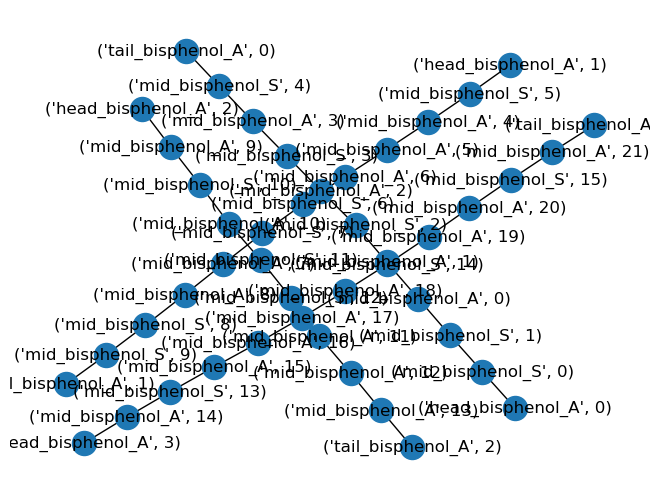

In [8]:
prior_child_handles : tuple[PrimitiveHandle, ...] = tuple(univprim.children_by_handle.keys())
for molprim_handle in prior_child_handles:
    univprim.expand(molprim_handle) # done in-place here, though Primitive.expanded() also exists
    
univprim.visualize_topology()
# print(univprim.hierarchy_summary(to_depth=2))

We can take this even further, "flattening" the entire hierarchy by bubbling the finest-resolution Primitives to be direct children of the root (universe).
In a hierarchy like the one we have here, there are multiplicatively more children as the resolution gets finer and finer (n_mols * units_per_mol * atoms_per_unit etc.), so this might take a minute!  

In [ ]:
univprim_flat = univprim.flattened() # doing this out-of-place to avoid modifying the hierarchy for final plotting, though by way of analogy, Primitive.flatten() also exists
univprim_flat.visualize_topology(with_labels=False, node_size=10) # some additional drawing config is useful here to let you see what's actually going on here

## Export to RDKit
For a system whose leaves are all atomic Primitives (i.e. have well-defined chemical element and bonded connections), we can export to RDKit.
This export requires a flattened system, so flattening will be applied if you haven't done it already. However, this is done on a copy of the hierarchy to avoid unexpected in-place modification.

In [ ]:
from mupt.interfaces.rdkit import primitive_to_rdkit

univmol = primitive_to_rdkit(univprim_flat) 
display(univmol)

In [ ]:
from pathlib import Path
from rdkit.Chem import SDWriter


save_dir : Path = Path('mupt-built_systems')
save_dir.mkdir(exist_ok=True)
save_path : Path = save_dir / f'ellipsoidal_backmap_{n_chains}x[{chain_len_min}-{chain_len_max}]-mer_chains.sdf'

with SDWriter(str(save_path)) as sdf_writer:
    sdf_writer.write(univmol) # DEV: write individual chains, with respective metadata one-at-a-time?
print(f'Exported {univmol.GetNumAtoms()}-atom system to {save_path}')

## Visualize placement of subprimitives [slow for larger systems, can skip if desired]
Here we inspect the intermediate levels of the unflattened copy of our molecular hierarchy to get a better sense of the topology and geometry of the subdivisions of the system.
Repeat units are drawn as Ellipsoidal/Spherical beads, while the atoms contained within them are drawn as point particles; this is governed by the `.shape` attribute of each respective Primitive.

In [ ]:
# NBVAL_SKIP
from anytree.iterators import LevelOrderGroupIter

import matplotlib.pyplot as plt
# %matplotlib ipympl

scale : float=16
aspect : float = 1/2
plt.close()
fig = plt.figure(figsize=(scale, scale*aspect))
fig.canvas.header_visible = False

levels : dict[int, tuple[Primitive]] = {i : grp for i, grp in enumerate(LevelOrderGroupIter(univprim))}

ellip_depth : int = 1
ax_ellip = fig.add_subplot(1, 2, ellip_depth, projection='3d')
ax_ellip.autoscale(enable=True)
ax_ellip.set_title(f'Spatial placement of repeat units\n(as ellipsoids) (depth {ellip_depth})')
for res_prim in levels[ellip_depth]:
    _ = ax_ellip.plot_surface(*res_prim.shape.surface_mesh(10, 10).T, color='c', alpha=0.5)

atom_depth : int = 2
ax_atomic = fig.add_subplot(1, 2, atom_depth, projection='3d')
ax_atomic.autoscale(enable=True)
ax_atomic.set_title(f'Spatial placement of atom\n(as point particles) (depth {atom_depth})')
for res_prim in levels[atom_depth]:
    _ = ax_atomic.scatter(*res_prim.shape.positions.T, color='r', marker='.', alpha=0.5)

In [ ]:
# from scipy.spatial.transform import Rotation, RigidTransform

# # optional; can apply a rigid transformation to the ENTIRE molecule at once - all sub-parts will be "carried along for the ride"
# random_rot = RigidTransform.from_rotation(Rotation.random())
# univprim.rigidly_transform(random_rot)